# TD3 Training Session

In [1]:
from RL.trainer import TD3TrajectoryTrainer

In [2]:
trainer = TD3TrajectoryTrainer(
    config_file="Settings/TD3_parameters.yaml",
    verbose=True,
    run_zero_waypoint_episode=True
)

[ TD3 ]> Loading configuration from Settings/TD3_parameters.yaml
[ TD3_COST ]> No configuration file provided, using default settings.


### Plotting simulation world from top

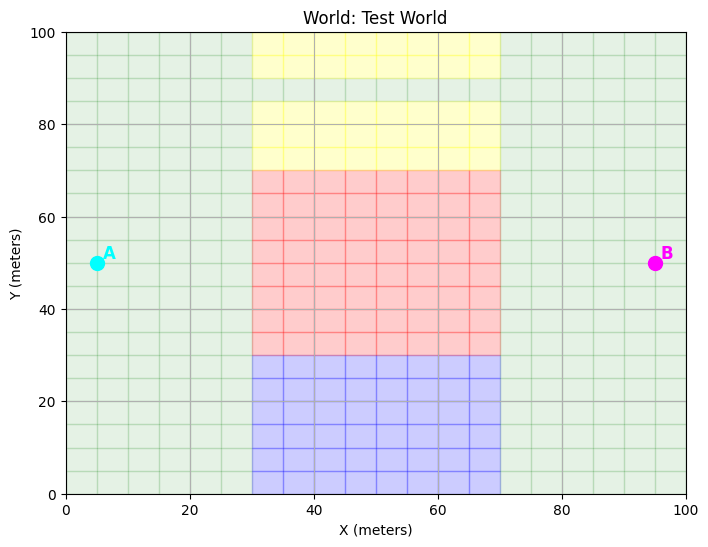

In [3]:
trainer.simulation_object.world.plot_world_from_top(A=trainer.start_point,
                                                        B=trainer.end_point)

### Plot a map of search regions
Here, boundary search for each reference point are plotted in a 2D map

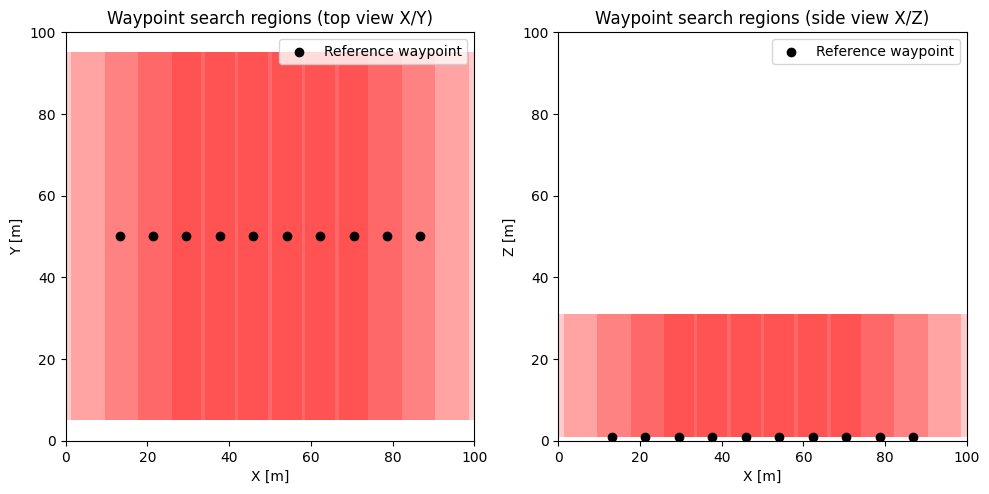

(<Figure size 1000x600 with 2 Axes>,
 array([<Axes: title={'center': 'Waypoint search regions (top view X/Y)'}, xlabel='X [m]', ylabel='Y [m]'>,
        <Axes: title={'center': 'Waypoint search regions (side view X/Z)'}, xlabel='X [m]', ylabel='Z [m]'>],
       dtype=object))

In [4]:
trainer.environment.plot_waypoint_search_regions(alpha=0.20, figsize=(10, 6))

## Starting training

[ TD3_COST ]> No configuration file provided, using default settings.
[ TD3_COST ]> No configuration file provided, using default settings.
[ TD3 ]> Model saved to RL\TD3\20251121_125929\td3_model
[ TD3_COST ]> No configuration file provided, using default settings.
[ TD3_COST ]> No configuration file provided, using default settings.
[ TD3_COST ]> No configuration file provided, using default settings.
[ TD3_COST ]> No configuration file provided, using default settings.
[ TD3_COST ]> No configuration file provided, using default settings.
[ TD3_COST ]> No configuration file provided, using default settings.
[ TD3_COST ]> No configuration file provided, using default settings.
[ TD3_COST ]> No configuration file provided, using default settings.
[ TD3_COST ]> No configuration file provided, using default settings.
[ TD3_COST ]> No configuration file provided, using default settings.
[ TD3_COST ]> No configuration file provided, using default settings.
[ TD3_COST ]> No configuration fi

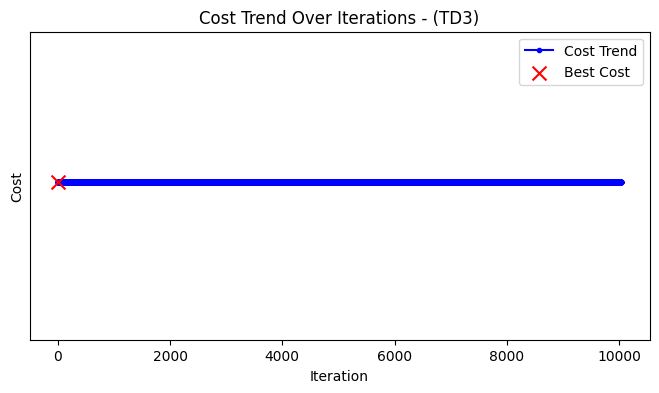

In [5]:
trainer.start_optimization()

In [6]:
print(f"Best cost: {trainer.best_cost}")
print(f"Episodes: {len(trainer.costs_history)}")
best_params = trainer.best_params
print("Best parameters found by RL agent:", best_params)

Best cost: 1100.0
Episodes: 10041
Best parameters found by RL agent: [{'x': 95.0, 'y': 50.0, 'z': 1.0, 'v': 15.0}]


[  ]> No configuration file provided, using default settings.
Final target reached at time: 7.86 s
Simulation completed in 1.62 seconds.
Costs: {'total_cost': 38468.05416197634, 'time_cost': 7.864, 'power_cost': 4.129069775390625, 'noise_cost': 38452.61420080815, 'completion_cost': 0.0, 'n_waypoints_completed': 1, 'tot_waypoints': 1}


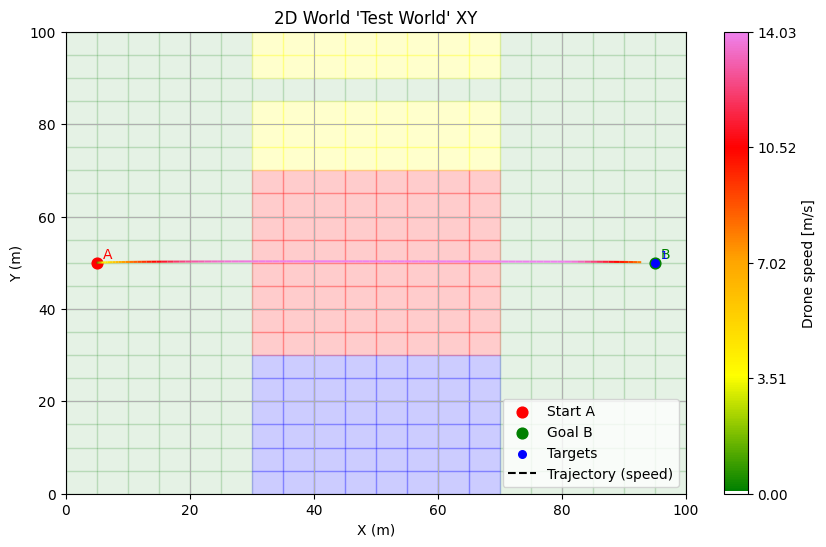

In [7]:
# Import best trajectory found by RL agent into main simulation for visualization and analysis
from main import *
from Optimizations.optimizer import Optimizer as CostWrapper
from Utils.plotting_functions import show2DWorld, show3DWorld


parameters = trainer.simulation_parameters
init_state = create_initial_state(*trainer.start_point)
waypoints_selected = best_params

thrust_max = get_max_thrust_from_rotor_model(parameters)
pid_gains = load_pid_gains(parameters)
quad_controller = create_quadcopter_controller(init_state, pid_gains, thrust_max, parameters)
drone = create_quadcopter_model(init_state, quad_controller, parameters)
world = World.load_world(parameters['world_data_path'])
noise_model = load_dnn_noise_model(parameters)

A = parameters['start_point']
B = parameters['end_point']

sim = Simulation(
    drone,
    world,
    waypoints_selected,
    dt=float(parameters['dt']),
    max_simulation_time=float(parameters['simulation_time']),
    frame_skip=int(parameters['frame_skip']),
    target_reached_threshold=float(parameters['threshold']),
    target_shift_threshold_distance=float(parameters['target_shift_threshold_distance']),
    noise_model=noise_model,
    generate_sound_emission_map=True,
    compute_psychoacoustics=False,
    noise_annoyance_radius=9,
)

cw = CostWrapper(sim, "")

cw.simulation_object.startSimulation(stop_at_target=True, use_static_target=False, verbose=True)
print(f"Costs: {cw.calculate_costs()}")
max_world_size = cw.simulation_object.world.max_world_size
show2DWorld(
    world, cw.simulation_object.positions, A, B, waypoints_selected, horiz_speed_history=cw.simulation_object.horiz_speed_history, vertical_speed_history=cw.simulation_object.vertical_speed_history)

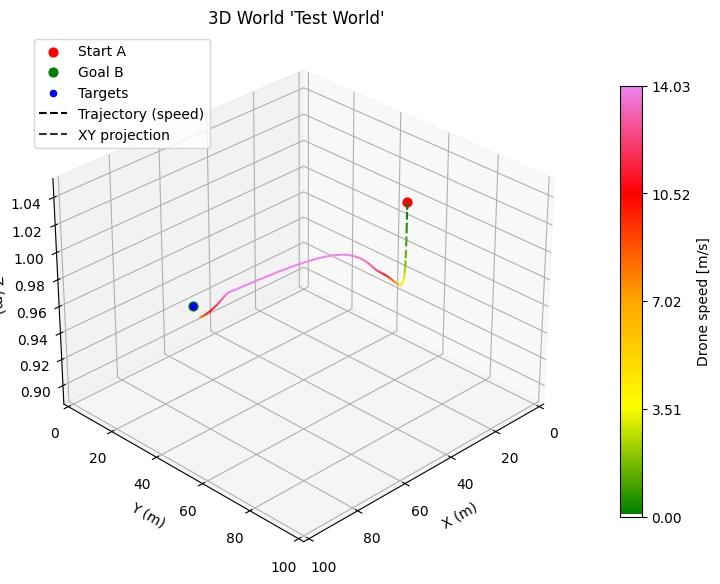

In [8]:
show3DWorld(
    world, cw.simulation_object.positions, A, B, waypoints_selected, 
    horiz_speed_history=cw.simulation_object.horiz_speed_history, 
    vertical_speed_history=cw.simulation_object.vertical_speed_history,
    view_pov=(30, 45))